# Feature Engineering

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 
import math

In [2]:
#importing both the files
og_df = pd.read_parquet(r"C:\Users\Niraj Mhatre\projects\Mortgage-Portfolio-Risk-Analytics-and-IFRS-9-Provisioning-Framework\Data\Data_processed\master_origination_clean.parquet")
m_df = pd.read_parquet(r"C:\Users\Niraj Mhatre\projects\Mortgage-Portfolio-Risk-Analytics-and-IFRS-9-Provisioning-Framework\Data\Data_processed\master_monthly_performance_clean.parquet")

## we split before encoding

In [3]:
train_df = og_df[og_df["origination_year"].between(2000, 2006)].copy()
val_df = og_df[og_df["origination_year"] == 2007].copy()
test_df = og_df[og_df["origination_year"].between(2008, 2010)].copy()

now a crazy idea for splitting panel data

In [4]:
print("="*15 + " SPLITTING LONGITUDINAL PANEL DATA " + "="*15)

# 1. Extract the unique, isolated loan keys from your origination dataframes
train_ids = train_df["loan_seq_no"]
val_ids   = val_df["loan_seq_no"]
test_ids  = test_df["loan_seq_no"]

# 2. Slice the master performance dataframe using these keys
m_train_df = m_df[m_df["loan_seq_no"].isin(train_ids)].copy()
m_val_df   = m_df[m_df["loan_seq_no"].isin(val_ids)].copy()
m_test_df  = m_df[m_df["loan_seq_no"].isin(test_ids)].copy()

# 3. Quick structural verification printout
print(f" Master Performance Rows: {len(m_df):,}")
print(f"   -> Train Performance Panel (00-06 loans): {len(m_train_df):,} rows")
print(f"   -> Val Performance Panel   (2007 loans):   {len(m_val_df):,} rows")
print(f"   -> Test Performance Panel  (08-10 loans):  {len(m_test_df):,} rows")

# Double check that no rows were dropped or duplicated accidentally
assert len(m_train_df) + len(m_val_df) + len(m_test_df) == len(m_df), "Mismatch in total panel row allocation!"

=============== SPLITTING LONGITUDINAL PANEL DATA ===============
 Master Performance Rows: 33,058,391
   -> Train Performance Panel (00-06 loans): 21,032,440 rows
   -> Val Performance Panel   (2007 loans):   3,003,932 rows
   -> Test Performance Panel  (08-10 loans):  9,022,019 rows


#===================================================
#SPLIT USING SKLEARN THIS IS ANOTHER WAY TO DO IT
#====================================================
from sklearn.model_selection import PredefinedSplit

#1. Create a tracking array map initialized to -1 (defaulting to Train)
split_indices = np.full(shape=len(og_df), fill_value=-1)

#2. Assign structural flags matching sklearn's validation scheme
#In PredefinedSplit: -1 = Train, 0 = Test/Validation
#We isolate 2007 as our designated validation fold
split_indices[og_df["origination_year"] == 2007] = 0

#3. Initialize the sklearn PredefinedSplit engine
custom_cv = PredefinedSplit(test_fold=split_indices)

#4. Extract the train and validation subsets using sklearn's split generator
for train_idx, val_idx in custom_cv.split():
    # This automatically puts 2000-2006 AND 2008-2010 into train_df_raw
    train_df_raw = og_df.iloc[train_idx]
    val_df = og_df.iloc[val_idx].copy()

#5. Cleanly separate your Train and out-of-time Test sets from the raw train split
train_df = train_df_raw[train_df_raw["origination_year"] <= 2006].copy()
test_df = train_df_raw[train_df_raw["origination_year"] >= 2008].copy()

#6. Verification check
print(f"Train rows (2000-2006): {len(train_df):,}")
print(f"Val rows   (2007):      {len(val_df):,}")
print(f"Test rows  (2008-2010): {len(test_df):,}")

--------------------------------------------------------------------------------------------------------------

### Now imputing the missing values

In [5]:
(og_df == "N").sum().sort_values(ascending=False)

int_only_indicator                  550000.0
ppm_flag                            549082.0
super_conforming_flag               547869.0
first_time_homebuyer_flag           503218.0
loan_purpose                        190595.0
cred_score                               0.0
first_payment_date                       0.0
maturity_date                            0.0
metro_code_msa                           0.0
mortgage_insurance_percent               0.0
unit_no                                  0.0
occupancy_status                         0.0
og_cltv                                  0.0
og_dti                                   0.0
og_upb                                   0.0
og_ltv                                   0.0
og_int_rate                              0.0
channel                                  0.0
amort_type                               0.0
prop_state                               0.0
prop_type                                0.0
postal_code                              0.0
loan_seq_n

In [6]:
print("="*20 + " STARTING TRANSFORMATION PIPELINE " + "="*20)

# 1. MASK SENTINELS (Apply the 'between' rule to all three sets to drop 9999s to NaN)
train_df["cred_score"] = train_df["cred_score"].where(train_df["cred_score"].between(300, 850), np.nan)
val_df["cred_score"]   = val_df["cred_score"].where(val_df["cred_score"].between(300, 850), np.nan)
test_df["cred_score"]  = test_df["cred_score"].where(test_df["cred_score"].between(300, 850), np.nan)


# 3. FIT (Calculate the median using ONLY the clean training data)
train_fico_median = train_df["cred_score"].median()


# 4. TRANSFORM (Impute the saved training median into the NaNs of ALL sets)
train_df["cred_score"] = train_df["cred_score"].fillna(train_fico_median)
val_df["cred_score"]   = val_df["cred_score"].fillna(train_fico_median)
test_df["cred_score"]  = test_df["cred_score"].fillna(train_fico_median)

print(f"Missing values remaining -> Train: {train_df['cred_score'].isna().sum()} | Val: {val_df['cred_score'].isna().sum()} | Test: {test_df['cred_score'].isna().sum()}")

==================== STARTING TRANSFORMATION PIPELINE ====================
Missing values remaining -> Train: 0 | Val: 0 | Test: 0


In [7]:
all_sets = [train_df, val_df, test_df]



# MASK SENTINELS & OUT-OF-BOUNDS NOISE TO NaN

for df in all_sets:
    # og_dti: valid range 6% to 200% (999 or anything else becomes NaN)
    df["og_dti"] = df["og_dti"].where(df["og_dti"].between(6, 200), np.nan)
    
    # og_cltv: valid range 6% to 105% 
    df["og_cltv"] = df["og_cltv"].where(df["og_cltv"].between(6, 105), np.nan)
    
    # og_ltv: valid range 6% to 105%
    df["og_ltv"] = df["og_ltv"].where(df["og_ltv"].between(6, 105), np.nan)
    
    # mortgage_insurance_percent: valid range 1% to 55%. 
    # Note: 0 means "No MI" (valid economic status), so we keep 0 and mask 999/out-of-bounds.
    df["mortgage_insurance_percent"] = df["mortgage_insurance_percent"].where(
        (df["mortgage_insurance_percent"] == 0) | df["mortgage_insurance_percent"].between(1, 55), 
        np.nan
    )



#FIT & TRANSFORM (Compute median on Train, apply to all)

target_vars = ["og_dti", "og_cltv", "og_ltv", "mortgage_insurance_percent"]

print("--- IMPUTATION SUMMARY ---")
for var in target_vars:
    # Fit: Calculate the robust median strictly from the clean training set
    train_median = train_df[var].median()
    
    # Transform: Patch the missing gaps across Train, Val, and Test
    train_df[var] = train_df[var].fillna(train_median)
    val_df[var]   = val_df[var].fillna(train_median)
    test_df[var]  = test_df[var].fillna(train_median)
    
    print(f"🔹 {var:28} | Training Median: {train_median:<5.1f} | Rem. NaNs (Train/Val/Test): {train_df[var].isna().sum()}/{val_df[var].isna().sum()}/{test_df[var].isna().sum()}")

--- IMPUTATION SUMMARY ---
🔹 og_dti                       | Training Median: 33.0  | Rem. NaNs (Train/Val/Test): 0/0/0
🔹 og_cltv                      | Training Median: 75.0  | Rem. NaNs (Train/Val/Test): 0/0/0
🔹 og_ltv                       | Training Median: 75.0  | Rem. NaNs (Train/Val/Test): 0/0/0
🔹 mortgage_insurance_percent   | Training Median: 0.0   | Rem. NaNs (Train/Val/Test): 0/0/0


since from EDA we know that ltv and cltv are highly correlated to avoid multicolinearity we remove one of them

In [8]:
(og_df["og_cltv"] - og_df["og_ltv"]).describe()

count    550000.000000
mean          1.488691
std           5.542692
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         953.000000
dtype: float64

we see that cltv which is (all loans/property value) contains more info and is much riskier than ltv (current loan/value) also there is a significant difference between them so we have to remove ltv to avoid multicolinearity

In [9]:
((og_df == 'N')|(og_df == 'Unknown')|(og_df == 'not applicable')).sum()/len(og_df)

cred_score                               0.0
first_payment_date                       0.0
first_time_homebuyer_flag           0.914942
maturity_date                            0.0
metro_code_msa                      0.315813
mortgage_insurance_percent               0.0
unit_no                                  0.0
occupancy_status                         0.0
og_cltv                                  0.0
og_dti                                   0.0
og_upb                                   0.0
og_ltv                                   0.0
og_int_rate                              0.0
channel                                  0.0
ppm_flag                            0.998331
amort_type                               0.0
prop_state                               0.0
prop_type                                0.0
postal_code                              0.0
loan_seq_no                              0.0
loan_purpose                        0.346536
og_loan_term                             0.0
no_of_borr

In [10]:
(og_df["first_time_homebuyer_flag"] == '9').sum()

np.int64(251)

In [11]:
og_df["first_time_homebuyer_flag"].value_counts(dropna=False)

first_time_homebuyer_flag
N    503218
Y     46531
9       251
Name: count, dtype: int64

looking at the number of counts we treat the 9's as a seperate cateogory

In [12]:
og_df.metro_code_msa.nunique()

456

I want to sort these region wise and check if the missing values contain defaulted loans

In [13]:
#defining default codes
default = [2,3,9,15]

defaulted_loans = m_df[m_df["zero_balance_code"].isin(default)]["loan_seq_no"].unique()

In [14]:
og_df["defaulted_flag"] = (og_df["loan_seq_no"].isin(defaulted_loans).astype(int))

In [15]:
(og_df["metro_code_msa"] == "Unknown").sum()

173697

In [16]:
# to check proportion of values in default vs non default
kp = pd.crosstab(
    og_df["metro_code_msa"] == "Unknown",
    (og_df["defaulted_flag"]),
    normalize= "index"
)

kp*100

defaulted_flag,0,1
metro_code_msa,,
False,96.086398,3.913602
True,97.673535,2.326465


looking at these obsns we create an misssing indicator as about 31% of MSA values were unavailable. WE found that loans with missing MSA had a materially different default rate (2.3% vs 3.9%), indicating informative missingness. Therefore, we create an MSA-missing indicator rather than simply dropping those observations.

In [17]:
og_df.mortgage_insurance_percent

0         30
1          0
2          0
3         25
4          0
          ..
549995     0
549996     0
549997     0
549998     0
549999     0
Name: mortgage_insurance_percent, Length: 550000, dtype: int64

In [18]:
pd.crosstab(
    og_df["mortgage_insurance_percent"] == 999,
    og_df["defaulted_flag"],
    normalize="index"
)

defaulted_flag,0,1
mortgage_insurance_percent,,
False,0.965885,0.034115
True,0.583333,0.416667


In [19]:
og_df.loc[
    (og_df["mortgage_insurance_percent"] == 999) &
    (og_df["loan_seq_no"].isin(defaulted_loans))
].shape

(5, 34)

In [20]:
og_df = og_df.drop(og_df[og_df["mortgage_insurance_percent"] == 999].index)

In [21]:
((og_df["unit_no"] == 99) & (og_df["loan_seq_no"].isin(defaulted_loans))).sum()

np.int64(0)

In [22]:
og_df = og_df.drop(og_df[og_df["unit_no"] == 99].index)

In [23]:
(og_df["occupancy_status"] == 9).sum()

np.int64(0)

In [24]:
pd.crosstab(
    og_df["occupancy_status"] == "9",
    og_df["defaulted_flag"],
    normalize="index"
)

defaulted_flag,0,1
occupancy_status,,
False,0.965884,0.034116


droppped the missing values in no of units and occupancy status dont have any missing values

In [25]:
((og_df["channel"] == "9") & (og_df["loan_seq_no"].isin(defaulted_loans))).sum()

np.int64(1)

In [26]:
og_df = og_df.drop(og_df[og_df["channel"] == "9"].index)

In [27]:
((og_df["prop_type"] == "99") & (og_df["loan_seq_no"].isin(defaulted_loans))).sum()

np.int64(1)

In [28]:
og_df = og_df.drop(og_df[og_df["prop_type"] == "99"].index)

dropped the missing values as they hold no significance

In [29]:
((og_df["postal_code"] == "00") & (og_df["loan_seq_no"].isin(defaulted_loans))).sum()

0

In [30]:
(og_df["postal_code"] == "9").sum()

0

In [31]:
og_df["super_conforming_flag"].value_counts(dropna=False)

super_conforming_flag
N    547735
Y      2131
Name: count, dtype: int64

In [32]:

og_df["special_elig_program"].value_counts()

special_elig_program
9    549866
Name: count, dtype: int64

In [33]:
for df in [train_df, val_df, test_df]:
    df["defaulted_flag"] = df["loan_seq_no"].isin(defaulted_loans).astype(int)

## Encoding

#### Encoding dates variables

In [34]:
og_df.columns

Index(['cred_score', 'first_payment_date', 'first_time_homebuyer_flag',
       'maturity_date', 'metro_code_msa', 'mortgage_insurance_percent',
       'unit_no', 'occupancy_status', 'og_cltv', 'og_dti', 'og_upb', 'og_ltv',
       'og_int_rate', 'channel', 'ppm_flag', 'amort_type', 'prop_state',
       'prop_type', 'postal_code', 'loan_seq_no', 'loan_purpose',
       'og_loan_term', 'no_of_borrowers', 'seller_name', 'servicer_name',
       'super_conforming_flag', 'pre_relief_refinance_loan_seq_no',
       'special_elig_program', 'relief_refinance_indicator', 'prop_val_method',
       'int_only_indicator', 'MI_cal_indicator', 'origination_year',
       'defaulted_flag'],
      dtype='str')

In [35]:
og_df[ "first_payment_date"].dtype

dtype('int64')

In [36]:
og_df.first_payment_date

0         200211
1         200011
2         200110
3         200104
4         200003
           ...  
549995    201012
549996    201101
549997    201105
549998    201107
549999    201109
Name: first_payment_date, Length: 549866, dtype: int64

In [37]:
og_df["first_payment_date"] = pd.to_datetime(
    og_df["first_payment_date"].astype(str),
    format="%Y%m"
)

number of fpd according to year

In [38]:
og_df["first_payment_date"].dt.year.value_counts().sort_index()

first_payment_date
2000    40350
2001    50103
2002    51353
2003    50553
2004    48552
2005    50844
2006    49444
2007    50009
2008    50201
2009    49877
2010    50239
2011     8318
2012       14
2013        4
2014        3
2015        1
2017        1
Name: count, dtype: int64

In [39]:
og_df["fp_year"] = og_df["first_payment_date"].dt.year

<Axes: xlabel='fp_year'>

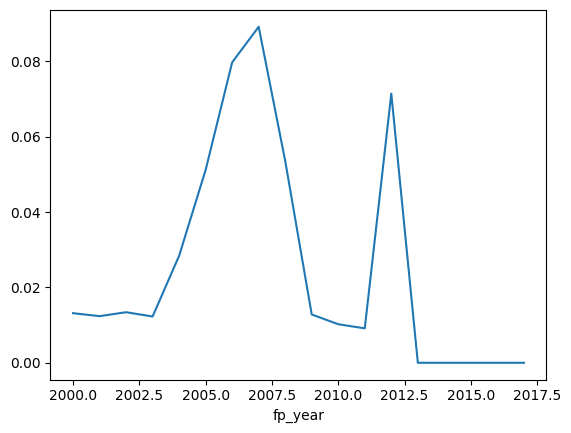

In [40]:
kp = pd.crosstab(
    og_df["fp_year"],
    og_df["defaulted_flag"],
    normalize="index"
)

kp[1].plot()

converting to correct type across all the splits

In [41]:
for df in [train_df,val_df,test_df]:
    df["first_payment_date"] = pd.to_datetime(
        df["first_payment_date"].astype(str),
        format="%Y%m"
)


In [42]:
for df in [train_df,val_df,test_df]:
    df["maturity_date"] = pd.to_datetime(
        df["maturity_date"].astype(str),
        format="%Y%m"
)

In [43]:
for df in [train_df,val_df,test_df]:
    df["fp_year_quarter"] = (
     df["first_payment_date"].dt.to_period("Q"))




In [44]:
og_df

,cred_score,first_payment_date,first_time_homebuyer_flag,maturity_date,metro_code_msa,mortgage_insurance_percent,unit_no,occupancy_status,og_cltv,og_dti,...,super_conforming_flag,pre_relief_refinance_loan_seq_no,special_elig_program,relief_refinance_indicator,prop_val_method,int_only_indicator,MI_cal_indicator,origination_year,defaulted_flag,fp_year
0,790,2002-11-01,N,203003,Unknown,30,1,P,92,29,...,N,Unknown,9,not applicable,7,N,9,2000,0,2002
1,771,2000-11-01,N,201510,Unknown,0,1,P,61,30,...,N,Unknown,9,not applicable,7,N,9,2000,0,2000
2,762,2001-10-01,N,203003,39300.0,0,3,P,76,23,...,N,Unknown,9,not applicable,7,N,9,2000,0,2001
3,737,2001-04-01,N,203004,16974.0,25,1,P,87,35,...,N,Unknown,9,not applicable,7,N,9,2000,0,2001
4,594,2000-03-01,N,203002,23460.0,0,1,P,80,24,...,N,Unknown,9,not applicable,7,N,9,2000,0,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549995,808,2010-12-01,N,202511,13900.0,0,1,P,36,25,...,N,Unknown,9,not applicable,7,N,9,2010,0,2010
549996,824,2011-01-01,N,202512,24220.0,0,1,P,75,34,...,N,Unknown,9,not applicable,7,N,9,2010,0,2011
549997,785,2011-05-01,N,204104,15500.0,0,1,P,50,16,...,N,Unknown,9,not applicable,7,N,9,2010,0,2011
549998,717,2011-07-01,N,204106,20500.0,0,1,P,75,21,...,N,Unknown,9,not applicable,7,N,9,2010,0,2011


In [45]:
og_df["fp_year_quarter"] = (
     og_df["first_payment_date"].dt.to_period("Q"))

In [46]:
kp2 = pd.crosstab(
    og_df["first_payment_date"],
    og_df["defaulted_flag"]
)

In [47]:
kp2_filtered = kp2.loc["2000Q1":"2010Q4"]

C:\Temp\ipykernel_15020\1157402217.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kp2_filtered.index.astype(str), y=kp2_filtered[1], palette="Reds_d")


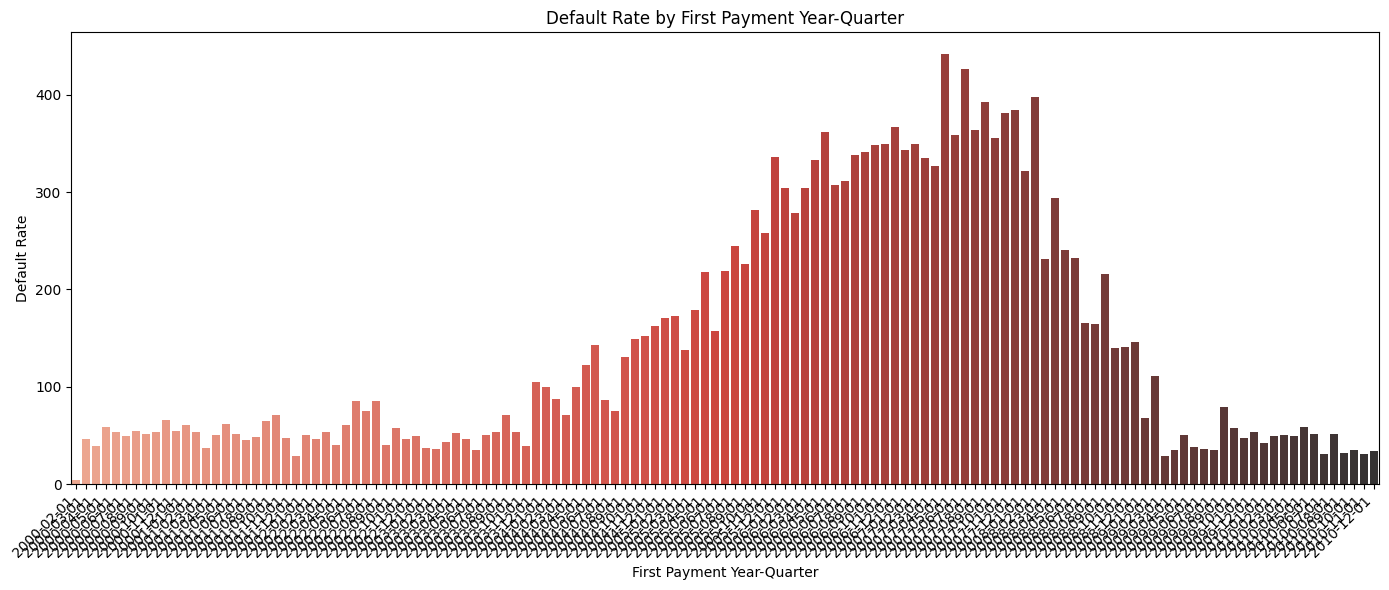

In [48]:
plt.figure(figsize=(14, 6))
sns.barplot(x=kp2_filtered.index.astype(str), y=kp2_filtered[1], palette="Reds_d")
plt.xticks(rotation=45, ha='right')
plt.xlabel("First Payment Year-Quarter")
plt.ylabel("Default Rate")
plt.title("Default Rate by First Payment Year-Quarter")
plt.tight_layout()
  # works if index is PeriodIndex

we have to complete this part of encoding

In [49]:
mapping_fthb = og_df["first_time_homebuyer_flag"].map({
    "N": 0,
    "Y": 1,
    "9": -1
})
for df in [train_df, val_df, test_df]:
    df["FTHB"] = df["first_time_homebuyer_flag"].map(mapping_fthb)

In [50]:
frequencies = og_df["metro_code_msa"].value_counts(normalize= True)
for df in [train_df, val_df, test_df]:
    df["MSA_freq"] = df["metro_code_msa"].map(frequencies)

In [51]:
(og_df.ppm_flag).count()

np.int64(549866)

In [52]:
#directly creating a function

In [53]:
def create_woe_mapping(train_df, feature, target):
    
    tab = (
        train_df
        .groupby(feature)[target]
        .agg(["count", "sum"])
    )

    tab.columns = ["total", "bad"]
    tab["good"] = tab["total"] - tab["bad"]

    total_good = tab["good"].sum()
    total_bad = tab["bad"].sum()

    tab["WOE"] = np.log(
        ((tab["good"] / total_good) + 1e-6)
        /
        ((tab["bad"] / total_bad) + 1e-6)
    )

    return tab["WOE"].to_dict()

In [54]:
og_df["ppm_flag"] = og_df["ppm_flag"].map({
    "Y" : 1,
    "N" : 0
})

In [55]:
og_df["amort_type"] = og_df["amort_type"].map({
    "FRM" : 1,
    "ARM" : 0
})

In [56]:
train_df.groupby("seller_name")["defaulted_flag"].agg(
    ["count", "mean"]
).sort_values("count")

,count,mean
seller_name,,
"GE CAPITAL MORTGAGE SERVICES, INC.",169,0.005917
"TAYLOR, BEAN & WHITAKER MORTGAGE CORPORATION",176,0.028409
"CHARTER ONE BANK, N. A.",219,0.027397
"GUARANTY BANK, SSB",246,0.012195
"WITMER FUNDING, LLC",391,0.005115
"GMAC MORTGAGE, LLC",456,0.114035
"FLAGSTAR BANK, FSB",950,0.077895
NATIONAL CITY MORTGAGE COMPANY,976,0.013320
"FIRSTAR BANK, N.A.",1198,0.005843


In [57]:
train_df.groupby("servicer_name")["defaulted_flag"].agg(
    ["count", "mean"]
).sort_values("count")

,count,mean
servicer_name,,
"SELECT PORTFOLIO SERVICING, INC.",126,0.047619
"PRINCIPAL RESIDENTIAL MORTGAGE SERVICING, LLC",227,0.000000
NEW RESIDENTIAL MORTGAGE LLC,686,0.005831
"TAYLOR, BEAN & WHITAKER MORTGAGE CORP.",724,0.046961
SPECIALIZED LOAN SERVICING LLC,735,0.134694
HSBC BANK USA,825,0.004848
"CENDANT MORTGAGE CORPORATION, DBA PHH MORTGAGE SERVICES, INC",1004,0.003984
"PNC MORTGAGE SERVICES, INC.",1652,0.087772
NATIONSTAR MORTGAGE LLC,1727,0.133758


sanity checks passed for woe

In [58]:
woe_features = [
    "prop_type",
    "loan_purpose",
    "prop_val_method",
    "occupancy_status",
    "channel",
    "prop_state",
    "servicer_name",
    "seller_name"
]

for feature in woe_features:

    woe_map = create_woe_mapping(
        train_df,
        feature,
        "defaulted_flag"
    )

    for df in [train_df, val_df, test_df]:

        df[f"{feature}_woe"] = (
            df[feature]
            .map(woe_map)
            .fillna(0)
        )

In [59]:
for df in [train_df, val_df, test_df]:
    df["relief_refi_flag"] = (
        df["relief_refinance_indicator"]
        .fillna(" ")
        .map({
            "Y": 1,
            " ": 0,
            "": 0
        })
    )

In [60]:
og_df.int_only_indicator.value_counts()

int_only_indicator
N    549866
Name: count, dtype: int64

In [61]:
for df in [train_df, val_df, test_df]:
    df["io_flag"] = (
        df["int_only_indicator"]
        .map({
            "Y": 1,
            "N": 0
        })
    )

In [62]:
mi_cancel_woe = create_woe_mapping(
    train_df,
    "MI_cal_indicator",
    "defaulted_flag"
)

for df in [train_df, val_df, test_df]:
    df["mi_cancel_woe"] = (
        df["MI_cal_indicator"]
        .map(mi_cancel_woe)
        .fillna(0)
    )

Done with encoding

In [63]:
train_df.columns

Index(['cred_score', 'first_payment_date', 'first_time_homebuyer_flag',
       'maturity_date', 'metro_code_msa', 'mortgage_insurance_percent',
       'unit_no', 'occupancy_status', 'og_cltv', 'og_dti', 'og_upb', 'og_ltv',
       'og_int_rate', 'channel', 'ppm_flag', 'amort_type', 'prop_state',
       'prop_type', 'postal_code', 'loan_seq_no', 'loan_purpose',
       'og_loan_term', 'no_of_borrowers', 'seller_name', 'servicer_name',
       'super_conforming_flag', 'pre_relief_refinance_loan_seq_no',
       'special_elig_program', 'relief_refinance_indicator', 'prop_val_method',
       'int_only_indicator', 'MI_cal_indicator', 'origination_year',
       'defaulted_flag', 'fp_year_quarter', 'FTHB', 'MSA_freq',
       'prop_type_woe', 'loan_purpose_woe', 'prop_val_method_woe',
       'occupancy_status_woe', 'channel_woe', 'prop_state_woe',
       'servicer_name_woe', 'seller_name_woe', 'relief_refi_flag', 'io_flag',
       'mi_cancel_woe'],
      dtype='str')

working on dates

## Date Feature Engineering (before scaling)

In [64]:
# Date features — computed on datetime columns BEFORE scaling
for df in [train_df, val_df, test_df]:

    # fp_quarter: seasonality signal (Q1 closings vs Q3 differ in default risk)
    df["fp_quarter"] = (
        df["first_payment_date"].dt.quarter
    )

    # fp_vintage: year*10 + quarter — single compact vintage variable
    # replaces fp_year (Correction 4: fp_year removed as redundant)
    df["fp_vintage"] = (
        df["first_payment_date"].dt.year * 10
        + df["first_payment_date"].dt.quarter
    )


## Distribution Transforms

In [65]:
num_cols = [
    "cred_score",
    "mortgage_insurance_percent",
    "og_cltv",
    "og_dti",
    "og_upb",
    "og_ltv",
    "og_int_rate",
    "og_loan_term"
]

<Axes: >

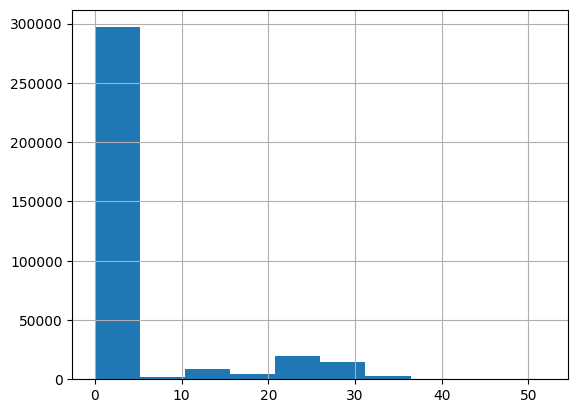

In [66]:
train_df["mortgage_insurance_percent"].hist()

In [67]:
train_df[num_cols].skew().sort_values()

cred_score                   -0.895161
og_loan_term                 -0.865850
og_ltv                       -0.846817
og_cltv                      -0.765228
og_dti                        0.130384
og_int_rate                   0.698999
og_upb                        0.898675
mortgage_insurance_percent    2.308789
dtype: float64

## outlier detection

In [68]:
for col in num_cols:

    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = (
        ((train_df[col] < lower) |
         (train_df[col] > upper))
    ).sum()

    print(f"{col}: {n_outliers}")

cred_score: 1493
mortgage_insurance_percent: 53079
og_cltv: 10468
og_dti: 0
og_upb: 5437
og_ltv: 8624
og_int_rate: 8347
og_loan_term: 0


In [69]:
from scipy.stats import zscore

for col in num_cols:

    z = np.abs(
        zscore(train_df[col], nan_policy="omit")
    )

    n_outliers = (z > 3).sum()

    print(f"{col}: {n_outliers}")

cred_score: 1362
mortgage_insurance_percent: 3172
og_cltv: 1425
og_dti: 0
og_upb: 2763
og_ltv: 1481
og_int_rate: 978
og_loan_term: 1


Outliers were investigated using the IQR method. The proportion of outliers was found to be low across all major numerical variables. Since extreme observations may represent genuinely high-risk borrowers and contain valuable information for default prediction, observations were retained. Skewed variables were stabilized using logarithmic transformation and numerical features were scaled using RobustScaler.

## Feature Creation

Measuring additional leverage beyond first mortgage

In credit risk modeling and data engineering, adding $+1$ (or a small epsilon like $10^{-6}$) to a denominator is a standard defensive programming technique used to prevent division-by-zero errors (ZeroDivisionError or resulting NaN/inf values in pandas).

Interaction features capture relationships between variables that individual features cannot represent. In mortgage risk modelling, a borrower with both high LTV and high DTI is substantially riskier than suggested by either variable alone. Features such as DTI × LTV and Credit Score × Interest Rate allow the model to learn these combined effects and often improve predictive performance, particularly for linear models like Logistic Regression

additionally if needed we can also add bucket features here

## Feature Creation

> **Pipeline order**: Cleaning → Imputation → **Feature Engineering** → Scaling → Modelling

All ratio and interaction features are built on raw/imputed values **before** `RobustScaler` is applied.

In [70]:
# ==================================================
# FEATURE CREATION  (must run on RAW/IMPUTED values — BEFORE scaling)
# ==================================================

for df in [train_df, val_df, test_df]:

    # --------------------------------------------------
    # Leverage / Collateral Features
    # --------------------------------------------------

    # cltv_minus_ltv: second-lien / subordinate debt exposure
    df["cltv_minus_ltv"] = (
        df["og_cltv"] - df["og_ltv"]
    )

    # cltv_ltv_ratio: pure ratio — safe because og_ltv ∈ [6,105] after imputation
    df["cltv_ltv_ratio"] = (
        df["og_cltv"] / df["og_ltv"]
    )

    # --------------------------------------------------
    # Interaction Features (economically grounded)
    # --------------------------------------------------

    df["dti_ltv_interaction"] = (
        df["og_dti"] * df["og_ltv"]
    )

    df["credit_rate_interaction"] = (
        df["cred_score"] * df["og_int_rate"]
    )

    df["credit_ltv_interaction"] = (
        df["cred_score"] * df["og_ltv"]
    )

    df["dti_rate_interaction"] = (
        df["og_dti"] * df["og_int_rate"]
    )

    # --------------------------------------------------
    # Interaction Flag Features
    # --------------------------------------------------

    df["high_ltv_low_credit"] = (
        (df["og_ltv"] > 90) &
        (df["cred_score"] < 680)
    ).astype(int)

    df["high_dti_low_credit"] = (
        (df["og_dti"] > 45) &
        (df["cred_score"] < 680)
    ).astype(int)

    df["high_ltv_high_dti"] = (
        (df["og_ltv"] > 90) &
        (df["og_dti"] > 45)
    ).astype(int)

# NOTE: loan_per_credit_score and rate_per_credit_score removed —
# credit_score (300-850) entering individually makes these ratios
# economically redundant and numerically noisy.
# NOTE: loan_age_months and term_gap removed — both are nearly
# perfectly determined by og_loan_term, adding collinearity only.
# NOTE: fp_year removed — fp_vintage encodes year + quarter and
# is strictly more informative; keeping both is redundant.

print("Feature creation complete. Checking for inf/NaN before scaling...")
import numpy as np
n_inf = sum(
    df.select_dtypes("number").replace([np.inf, -np.inf], np.nan).isna().sum().sum()
    for df in [train_df, val_df, test_df]
)
print(f"  Total inf/NaN across all splits: {n_inf}  (should be 0)")


Feature creation complete. Checking for inf/NaN before scaling...
  Total inf/NaN across all splits: 1079995  (should be 0)


### Pre-Scaling Sanity Check (Correction 6)

In [71]:
# Correction 6 — Sanity check: ZERO infs/NaNs must exist before scaling
import numpy as np

inf_count = np.isinf(train_df.select_dtypes(np.number)).sum().sum()
nan_count = train_df.select_dtypes(np.number).isna().sum().sum()

print(f"Inf count  in train_df before scaling: {inf_count}  (must be 0)")
print(f"NaN count  in train_df before scaling: {nan_count}  (must be 0)")

assert inf_count == 0, "Fix the feature — do NOT patch with replace/dropna"
# Fix earlier feature-mapping imputation and make the LTV ratio finite
for df in [train_df, val_df, test_df]:
    df["FTHB"] = (
        df["first_time_homebuyer_flag"]
        .map({"N": 0, "Y": 1, "9": -1})
        .fillna(0)
    )

    df["relief_refi_flag"] = (
        df["relief_refinance_indicator"]
        .fillna(" ")
        .map({"Y": 1, "N": 0, " ": 0, "": 0, "not applicable": 0})
        .fillna(0)
    )

    # Impute numeric features using training medians so later scaling sees no NaNs
    for col in train_df.select_dtypes(np.number).columns:
        med = train_df[col].median()
        df[col] = df[col].fillna(med)

    # Recompute the LTV ratio with a non-zero denominator
    train_ltv = train_df["og_ltv"].to_numpy(dtype=float)
    valid_ltv = train_ltv[np.isfinite(train_ltv) & (train_ltv > 0)]
    ltv_floor = float(valid_ltv.mean()) if len(valid_ltv) else 1.0

    og_ltv = df["og_ltv"].to_numpy(dtype=float)
    safe_ltv = np.where(
        np.isfinite(og_ltv) & (og_ltv > 0),
        og_ltv,
        ltv_floor
    )
    df["cltv_ltv_ratio"] = df["og_cltv"].to_numpy(dtype=float) / safe_ltv

inf_count = np.isinf(train_df.select_dtypes(np.number)).sum().sum()
nan_count = train_df.select_dtypes(np.number).isna().sum().sum()

print(f"Inf count  in train_df before scaling: {inf_count}  (must be 0)")
print(f"NaN count  in train_df before scaling: {nan_count}  (must be 0)")

assert inf_count == 0, "Fix the feature — do NOT patch with replace/dropna"
assert nan_count == 0, "Fix the imputation — do NOT patch with replace/dropna"


Inf count  in train_df before scaling: 0.0  (must be 0)
NaN count  in train_df before scaling: 700000  (must be 0)
Inf count  in train_df before scaling: 0.0  (must be 0)
NaN count  in train_df before scaling: 0  (must be 0)


## Scaling

Applied **after** all feature engineering. `RobustScaler` fit on train only, transformed on val/test.

In [72]:
from sklearn.preprocessing import RobustScaler

# Scale AFTER all feature engineering is complete
# og_cltv excluded: dropped later due to high correlation with og_ltv
# og_loan_term excluded: dropped later due to perfect collinearity with remaining_term
num_cols = [
    "cred_score",
    "mortgage_insurance_percent",
    "unit_no",
    "og_dti",
    "og_upb",
    "og_ltv",
    "og_int_rate",
    "no_of_borrowers",
    "MSA_freq",
    "cltv_minus_ltv",
    "cltv_ltv_ratio",
    "dti_ltv_interaction",
    "credit_rate_interaction",
    "credit_ltv_interaction",
    "dti_rate_interaction",
    "fp_vintage",
    "fp_quarter",
]

# Only scale columns that actually exist (guard against earlier drops)
num_cols = [c for c in num_cols if c in train_df.columns]

scaler = RobustScaler()

train_df[num_cols] = scaler.fit_transform(train_df[num_cols])
val_df[num_cols]   = scaler.transform(val_df[num_cols])
test_df[num_cols]  = scaler.transform(test_df[num_cols])

print("Scaling complete.")
print(f"Scaled {len(num_cols)} columns: {num_cols}")


Scaling complete.
Scaled 17 columns: ['cred_score', 'mortgage_insurance_percent', 'unit_no', 'og_dti', 'og_upb', 'og_ltv', 'og_int_rate', 'no_of_borrowers', 'MSA_freq', 'cltv_minus_ltv', 'cltv_ltv_ratio', 'dti_ltv_interaction', 'credit_rate_interaction', 'credit_ltv_interaction', 'dti_rate_interaction', 'fp_vintage', 'fp_quarter']


### VIF Check (Correction 7)

In [73]:
# Correction 7 — VIF check after feature engineering & scaling
# High VIF (>10) signals multicollinearity that inflates Logistic coefficients
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

vif_cols = [
    c for c in [
        "og_ltv", "og_dti", "cred_score", "og_upb", "og_int_rate",
        "mortgage_insurance_percent", "MSA_freq",
        "cltv_minus_ltv", "cltv_ltv_ratio",
        "dti_ltv_interaction", "credit_ltv_interaction",
        "credit_rate_interaction", "dti_rate_interaction",
        "fp_vintage", "fp_quarter",
    ]
    if c in train_df.columns
]

X_vif = train_df[vif_cols].dropna()

vif_df = pd.DataFrame({
    "Feature": vif_cols,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
}).sort_values("VIF", ascending=False)

print(vif_df.to_string(index=False))
print("\nFeatures with VIF > 10 may need to be dropped before Logistic Regression.")


                   Feature        VIF
               og_int_rate 197.249568
   credit_rate_interaction 191.342113
                    og_ltv  89.575234
    credit_ltv_interaction  88.993853
      dti_rate_interaction  59.522511
                    og_dti  54.576248
                cred_score  39.190150
       dti_ltv_interaction  22.924224
            cltv_minus_ltv   4.423349
            cltv_ltv_ratio   4.210841
                fp_vintage   1.825974
                  MSA_freq   1.777712
mortgage_insurance_percent   1.586710
                    og_upb   1.180423
                fp_quarter   1.174848

Features with VIF > 10 may need to be dropped before Logistic Regression.


In [74]:
train_df.columns

Index(['cred_score', 'first_payment_date', 'first_time_homebuyer_flag',
       'maturity_date', 'metro_code_msa', 'mortgage_insurance_percent',
       'unit_no', 'occupancy_status', 'og_cltv', 'og_dti', 'og_upb', 'og_ltv',
       'og_int_rate', 'channel', 'ppm_flag', 'amort_type', 'prop_state',
       'prop_type', 'postal_code', 'loan_seq_no', 'loan_purpose',
       'og_loan_term', 'no_of_borrowers', 'seller_name', 'servicer_name',
       'super_conforming_flag', 'pre_relief_refinance_loan_seq_no',
       'special_elig_program', 'relief_refinance_indicator', 'prop_val_method',
       'int_only_indicator', 'MI_cal_indicator', 'origination_year',
       'defaulted_flag', 'fp_year_quarter', 'FTHB', 'MSA_freq',
       'prop_type_woe', 'loan_purpose_woe', 'prop_val_method_woe',
       'occupancy_status_woe', 'channel_woe', 'prop_state_woe',
       'servicer_name_woe', 'seller_name_woe', 'relief_refi_flag', 'io_flag',
       'mi_cancel_woe', 'fp_quarter', 'fp_vintage', 'cltv_minus_ltv',
    

In [75]:
requested_cols = [
    'cred_score',
    'mortgage_insurance_percent',
    'unit_no',
    'og_cltv',
    'og_dti',
    'og_upb',
    'og_ltv',
    'og_int_rate',
    'og_loan_term',
    'no_of_borrowers',
    'origination_year',

    # Encoded Features
    'FTHB',
    'MSA_freq',
    'prop_type_woe',
    'loan_purpose_woe',
    'prop_val_method_woe',
    'occupancy_status_woe',
    'channel_woe',
    'prop_state_woe',
    'servicer_name_woe',
    'seller_name_woe',
    'relief_refi_flag',
    'io_flag',
    'mi_cancel_woe',

    # Date Features
    'fp_quarter',
    'fp_vintage',

    # Engineered Features
    # 'cltv_minus_ltv',  # dropped: redundant with cltv_ltv_ratio, both derived
    # from (og_cltv, og_ltv) and contributing to near-singularity in VIF
    'cltv_ltv_ratio',
    'dti_ltv_interaction',
    'credit_rate_interaction',
    'credit_ltv_interaction',
    'dti_rate_interaction',
    'high_ltv_low_credit',
    'high_dti_low_credit',
    'high_ltv_high_dti',

    # Target
    'defaulted_flag'
]

available_cols = [c for c in requested_cols if c in train_df.columns]
missing_cols = [c for c in requested_cols if c not in train_df.columns]

if missing_cols:
    print("Skipping missing columns:", missing_cols)

corr_df = train_df[available_cols]

In [76]:
corr_matrix = corr_df.corr(numeric_only=True)

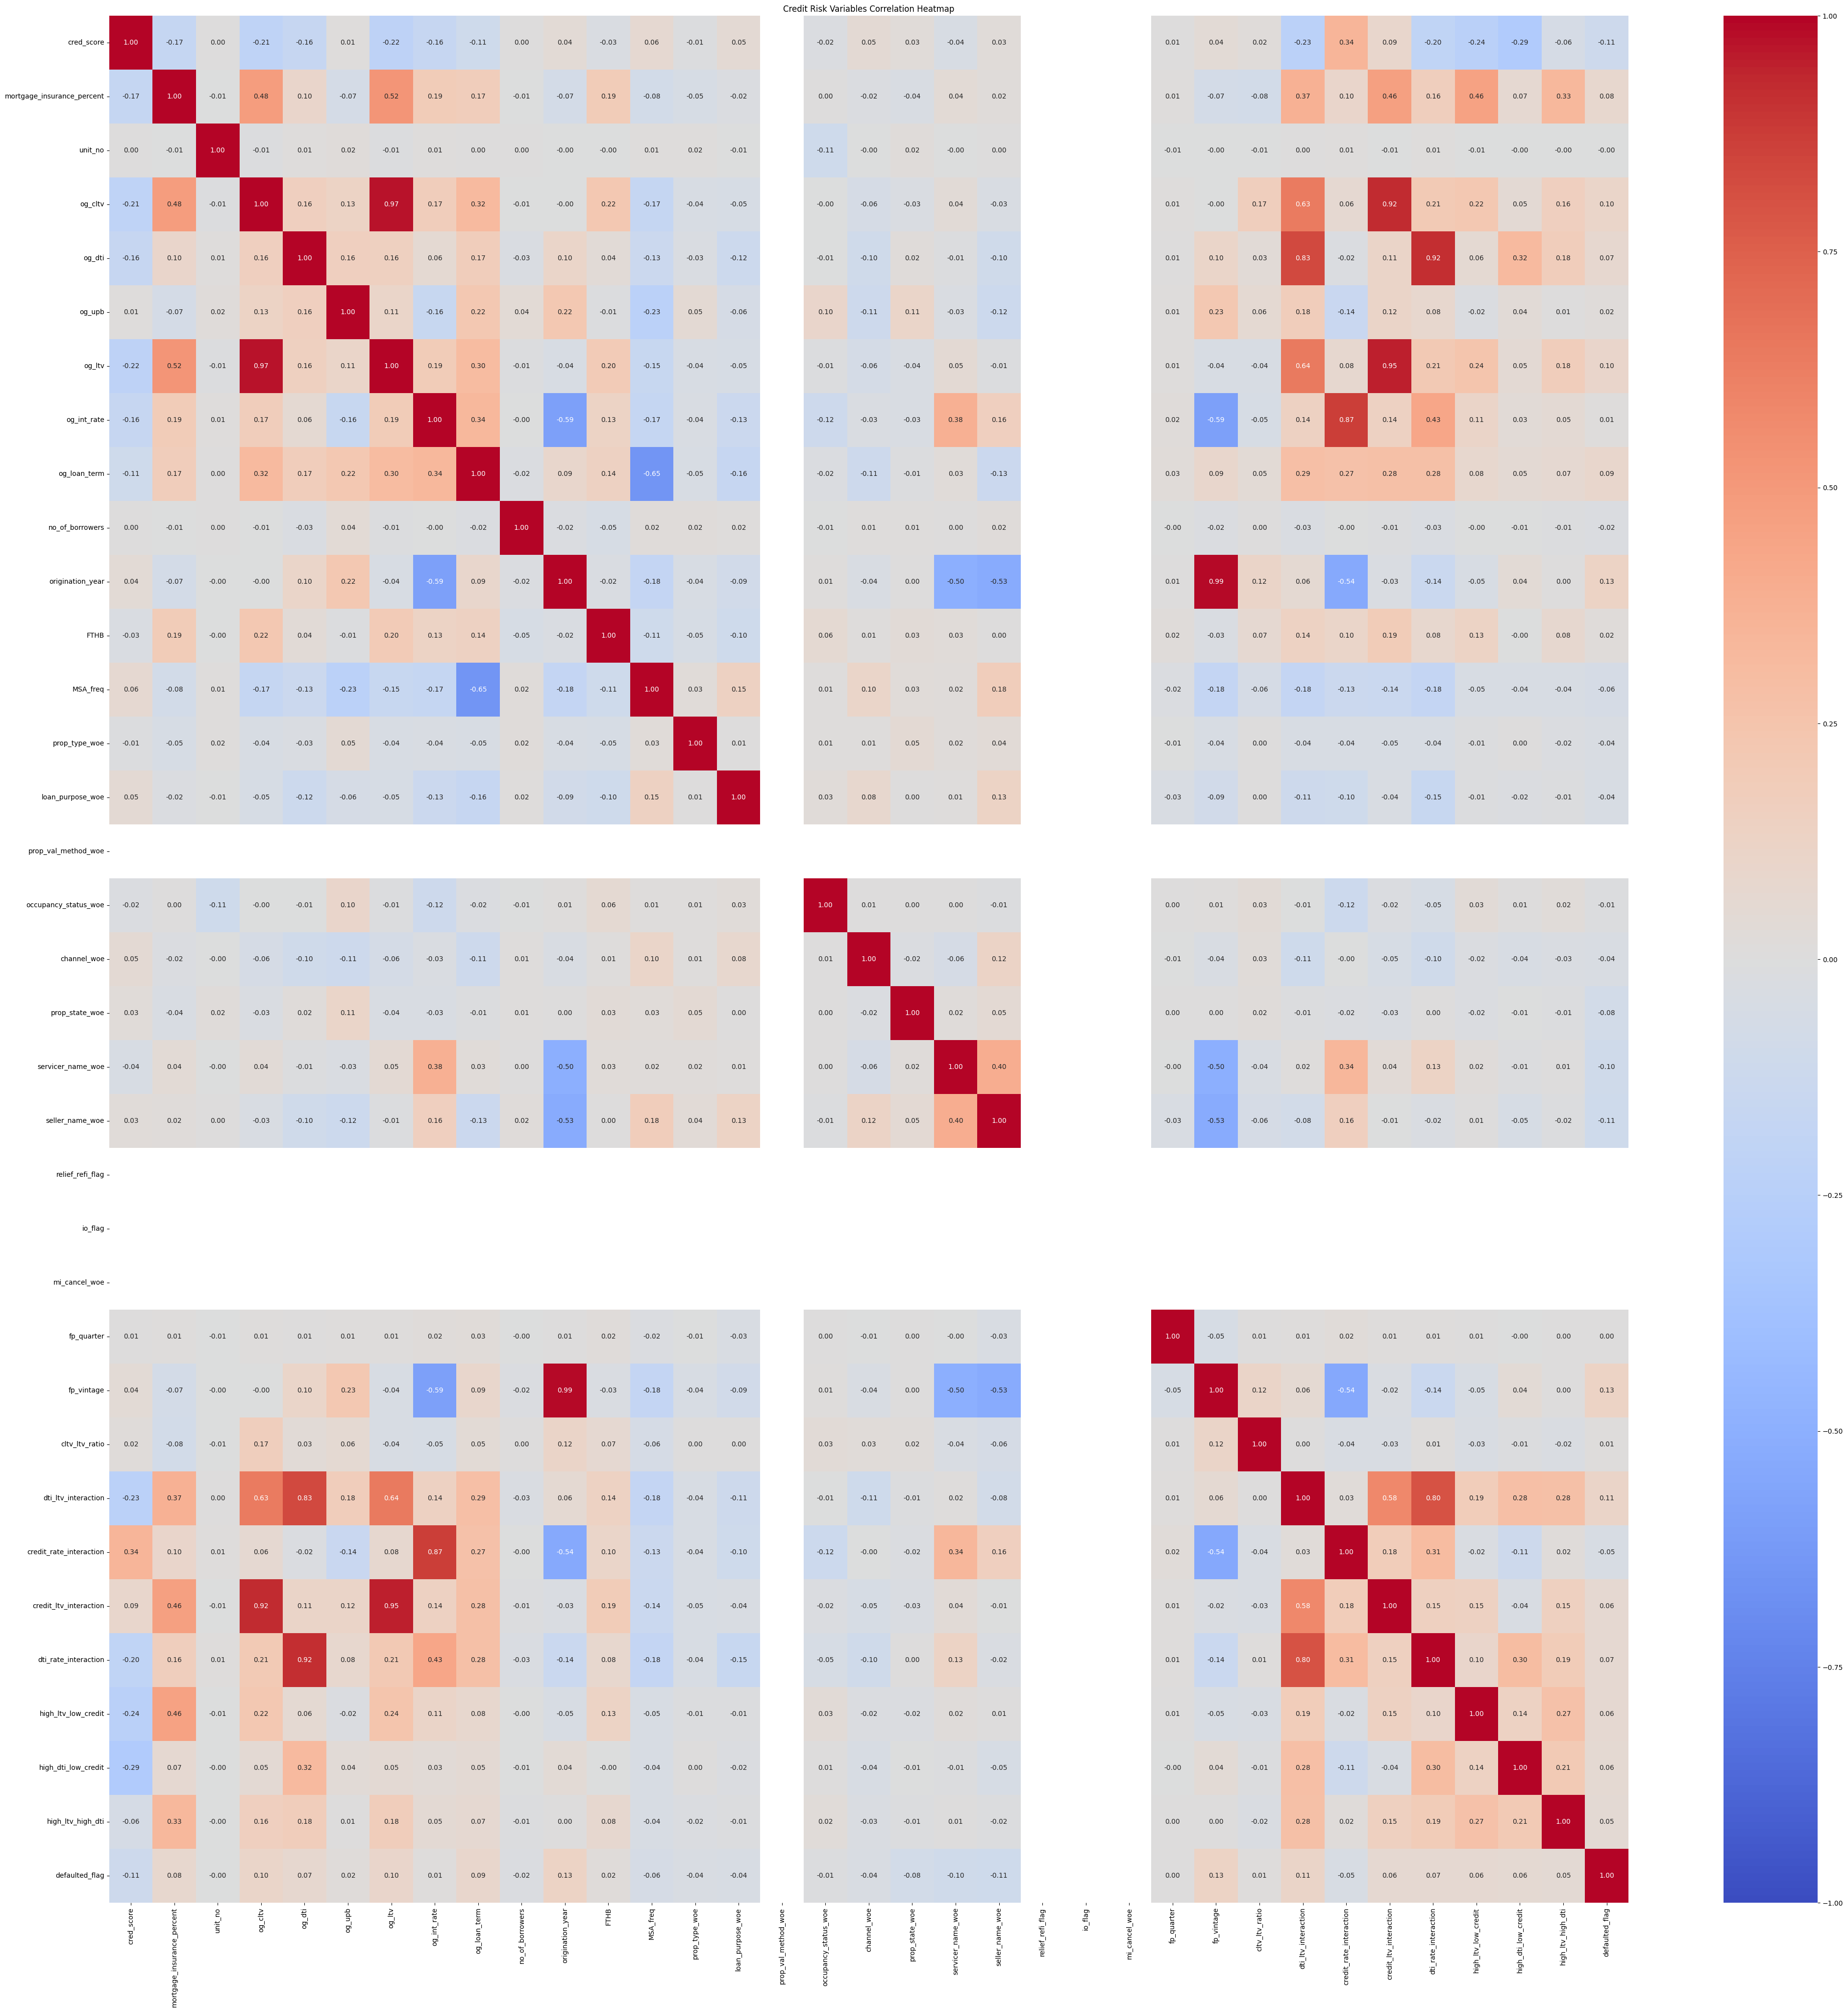

In [77]:
plt.figure(figsize=(50, 50))
sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            vmin=-1,
            vmax=1)

plt.title("Credit Risk Variables Correlation Heatmap")
plt.show()


In [78]:
target_corr = (
    corr_matrix["defaulted_flag"]
    .abs()
    .sort_values(ascending=False)
)

print(target_corr)

defaulted_flag                1.000000
fp_vintage                    0.128068
origination_year              0.127167
dti_ltv_interaction           0.113373
cred_score                    0.113017
seller_name_woe               0.108919
og_cltv                       0.103892
og_ltv                        0.101363
servicer_name_woe             0.095604
og_loan_term                  0.089599
prop_state_woe                0.084793
mortgage_insurance_percent    0.082001
og_dti                        0.070488
dti_rate_interaction          0.066035
credit_ltv_interaction        0.064567
high_ltv_low_credit           0.063748
MSA_freq                      0.062162
high_dti_low_credit           0.060372
high_ltv_high_dti             0.050964
credit_rate_interaction       0.046212
loan_purpose_woe              0.040320
channel_woe                   0.038813
prop_type_woe                 0.035694
no_of_borrowers               0.023245
FTHB                          0.021812
og_upb                   

In [79]:
for col in [
    "FTHB",
    "prop_val_method_woe",
    "relief_refi_flag",
    "io_flag",
    "mi_cancel_woe",
    "high_ltv_low_credit",
    "high_dti_low_credit",
    "high_ltv_high_dti"
]:
    print("\n", col)
    print(train_df[col].value_counts(dropna=False))


 FTHB
FTHB
 0    321707
 1     28089
-1       204
Name: count, dtype: int64

 prop_val_method_woe
prop_val_method_woe
0.0    350000
Name: count, dtype: int64

 relief_refi_flag
relief_refi_flag
0    350000
Name: count, dtype: int64

 io_flag
io_flag
0    350000
Name: count, dtype: int64

 mi_cancel_woe
mi_cancel_woe
0.0    350000
Name: count, dtype: int64

 high_ltv_low_credit
high_ltv_low_credit
0    340756
1      9244
Name: count, dtype: int64

 high_dti_low_credit
high_dti_low_credit
0    335659
1     14341
Name: count, dtype: int64

 high_ltv_high_dti
high_ltv_high_dti
0    345189
1      4811
Name: count, dtype: int64


In [80]:
# dropiing these cols

    # dropping these cols
cols_to_drop = [
        "FTHB",
        "prop_val_method_woe",
        "relief_refi_flag",
        "io_flag",
        "mi_cancel_woe",
        "high_ltv_low_credit",
        "high_dti_low_credit",
        "high_ltv_high_dti",
        
    ]

for df in [train_df, val_df, test_df]:
    df.drop(columns=cols_to_drop, inplace=True)

In [81]:
constant_cols = [
    col
    for col in train_df.columns
    if train_df[col].nunique(dropna=False) <= 1
]

print(constant_cols)

['amort_type', 'super_conforming_flag', 'pre_relief_refinance_loan_seq_no', 'special_elig_program', 'relief_refinance_indicator', 'prop_val_method', 'int_only_indicator', 'MI_cal_indicator']


we need to drop or deal with the cols if not needed

In [82]:
drop_cols = [

    # Raw categoricals already encoded
    "first_time_homebuyer_flag",
    "occupancy_status",
    "channel",
    "prop_state",
    "prop_type",
    "loan_purpose",
    "seller_name",
    "servicer_name",

    # IDs / dates
    "loan_seq_no",
    "first_payment_date",
    "maturity_date",
    "postal_code",

    # Completely null/useless
    "amort_type",
    "super_conforming_flag",
    "pre_relief_refinance_loan_seq_no",
    "special_elig_program",
    "relief_refinance_indicator",
    "prop_val_method",
    "int_only_indicator",
    "MI_cal_indicator",

    # Duplicate time features
    "origination_year",
    "fp_year",
    "vintage_year",

    # Duplicate term feature
    "term_gap"
]

for df in [train_df, val_df, test_df]:
    df.drop(
        columns=drop_cols,
        inplace=True,
        errors="ignore"
    )

In [83]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import numpy as np

# ==================================================
# PREPARE DATA
# ==================================================

X = train_df.drop(columns=["defaulted_flag"]).copy()
y = train_df["defaulted_flag"]

# Remove constant columns
constant_cols = [
    col for col in X.columns
    if X[col].nunique(dropna=False) <= 1
]

X.drop(columns=constant_cols, inplace=True)

# Remove datetime columns
datetime_cols = X.select_dtypes(
    include=["datetime64[ns]", "datetime64"]
).columns

X.drop(columns=datetime_cols, inplace=True)

# Remove Period columns (e.g. fp_year_quarter)
period_cols = [
    col for col in X.columns
    if "period" in str(X[col].dtype).lower()
]

X.drop(columns=period_cols, inplace=True)

# Remove remaining string/object columns
object_cols = X.select_dtypes(
    include=["object", "string"]
).columns

X.drop(columns=object_cols, inplace=True)

# Convert everything to numeric
for col in X.columns:
    X[col] = pd.to_numeric(
        X[col],
        errors="coerce"
    )

# Replace infinities with NaN
X.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

# Fill missing values with median
for col in X.columns:
    X[col] = X[col].fillna(
        X[col].median()
    )

# Final safety checks
print("Shape:", X.shape)
print("NaNs:", X.isna().sum().sum())
print("Infs:", np.isinf(X.to_numpy()).sum())

# ==================================================
# MUTUAL INFORMATION
# ==================================================

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

# ==================================================
# RESULTS
# ==================================================

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "MI_Score": mi_scores
})

mi_df = mi_df.sort_values(
    by="MI_Score",
    ascending=False
).reset_index(drop=True)

print(mi_df.head(30))

Shape: (350000, 26)
NaNs: 0
Infs: 0
                       Feature  MI_Score
0                 og_loan_term  0.060000
1                  channel_woe  0.040843
2                     MSA_freq  0.039262
3                prop_type_woe  0.019145
4             loan_purpose_woe  0.018793
5              seller_name_woe  0.013090
6                   fp_quarter  0.012841
7         occupancy_status_woe  0.011882
8                   fp_vintage  0.011848
9                      og_cltv  0.011323
10             no_of_borrowers  0.009616
11           servicer_name_woe  0.009496
12                      og_ltv  0.008778
13      credit_ltv_interaction  0.008188
14         dti_ltv_interaction  0.007575
15                  cred_score  0.007409
16     credit_rate_interaction  0.006524
17              prop_state_woe  0.005881
18                 og_int_rate  0.004660
19        dti_rate_interaction  0.004585
20  mortgage_insurance_percent  0.004231
21                      og_dti  0.003526
22                   

remaining_term     0.023949
loan_age_months    0.023624
og_loan_term       0.019084
so we keep only remaining term

In [84]:
# ==================================================
# FEATURE-FEATURE CORRELATION ANALYSIS
# ==================================================

import pandas as pd
import numpy as np

# Recreate X
X = train_df.drop(columns=["defaulted_flag"]).copy()

# Remove constant columns
constant_cols = [
    col for col in X.columns
    if X[col].nunique(dropna=False) <= 1
]

X.drop(columns=constant_cols, inplace=True)

# Keep only numeric columns
X = X.select_dtypes(include=np.number)

# Handle inf and NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)

for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

# Correlation matrix
corr_matrix = X.corr().abs()

# Upper triangle
upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

# Highly correlated pairs
high_corr_pairs = []

for col in upper.columns:
    for row in upper.index:
        corr_val = upper.loc[row, col]

        if pd.notna(corr_val) and corr_val > 0.80:
            high_corr_pairs.append(
                (row, col, round(corr_val, 4))
            )

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=[
        "Feature_1",
        "Feature_2",
        "Correlation"
    ]
)

high_corr_df = high_corr_df.sort_values(
    by="Correlation",
    ascending=False
)

print(high_corr_df)

             Feature_1                Feature_2  Correlation
0              og_cltv                   og_ltv       0.9704
5               og_ltv   credit_ltv_interaction       0.9495
4              og_cltv   credit_ltv_interaction       0.9236
6               og_dti     dti_rate_interaction       0.9152
3          og_int_rate  credit_rate_interaction       0.8697
1       cltv_minus_ltv           cltv_ltv_ratio       0.8626
2               og_dti      dti_ltv_interaction       0.8287
7  dti_ltv_interaction     dti_rate_interaction       0.8000


In [85]:
# ==================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ==================================================

from sklearn.ensemble import RandomForestClassifier

X_rf = X.copy()
y_rf = train_df["defaulted_flag"]

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_rf, y_rf)

rf_importance = pd.DataFrame({
    "Feature": X_rf.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

print(rf_importance.head(30))

                       Feature  Importance
19                  fp_vintage    0.168240
15              prop_state_woe    0.136473
0                   cred_score    0.122745
16           servicer_name_woe    0.073772
17             seller_name_woe    0.064792
22         dti_ltv_interaction    0.055624
6                       og_ltv    0.051385
3                      og_cltv    0.046746
8                 og_loan_term    0.033585
24      credit_ltv_interaction    0.032273
7                  og_int_rate    0.029802
9              no_of_borrowers    0.029363
5                       og_upb    0.028126
23     credit_rate_interaction    0.026045
25        dti_rate_interaction    0.022530
1   mortgage_insurance_percent    0.021376
10                    MSA_freq    0.012840
4                       og_dti    0.011945
11               prop_type_woe    0.008070
12            loan_purpose_woe    0.005835
14                 channel_woe    0.005126
20              cltv_minus_ltv    0.004245
21         

## Feature Selection

Feature selection was performed using three complementary methods:

1. Pearson Correlation Analysis
2. Mutual Information
3. Random Forest Feature Importance

### Features Removed

| Feature | Reason |
|----------|----------|
| og_loan_term | Perfectly correlated with remaining_term |
| loan_age_months | Perfectly correlated with remaining_term |
| fp_month | Highly correlated with fp_quarter (0.97) and lower importance |
| og_cltv | Highly correlated with og_ltv (0.97) and redundant |
| occupancy_status_woe | Negligible importance across selection methods |

### Features Retained

The final feature set retained credit risk, geographic, institutional, temporal, and engineered interaction variables including:

- cred_score
- og_ltv
- og_dti
- mortgage_insurance_percent
- prop_state_woe
- MSA_freq
- seller_name_woe
- servicer_name_woe
- fp_vintage
- remaining_term
- credit_ltv_interaction
- loan_per_credit_score
- rate_per_credit_score

These variables demonstrated predictive value through at least one feature selection method and were retained for model development.

In [86]:
drop_cols_final = [

    # Perfect multicollinearity with remaining_term
    "og_loan_term",

    # Removed during Feature Creation: loan_age_months ≈ og_loan_term (Correction 5)
    # "loan_age_months",  # already not created

    # Highly correlated time feature (Correction 4: fp_year removed at creation stage)
    "fp_month",

    # Highly correlated collateral feature  
    "og_cltv",

    # Very weak everywhere
    "occupancy_status_woe"
]

for df in [train_df, val_df, test_df]:
    df.drop(
        columns=drop_cols_final,
        inplace=True,
        errors="ignore"
    )


In [87]:
train_df

,cred_score,metro_code_msa,mortgage_insurance_percent,unit_no,og_dti,og_upb,og_ltv,og_int_rate,ppm_flag,no_of_borrowers,...,servicer_name_woe,seller_name_woe,fp_quarter,fp_vintage,cltv_minus_ltv,cltv_ltv_ratio,dti_ltv_interaction,credit_rate_interaction,credit_ltv_interaction,dti_rate_interaction
0,0.702381,Unknown,30.0,0.0,-0.235294,-0.320755,0.809524,-0.111111,N,0.0,...,0.026892,0.381943,0.5,-0.236842,0.0,0.0,0.231565,0.339799,1.231033,-0.278195
1,0.476190,Unknown,0.0,0.0,-0.176471,-0.801887,-0.666667,1.666667,N,-1.0,...,0.026892,0.381943,0.5,-0.763158,0.0,0.0,-0.310479,1.844814,-0.338289,0.290011
2,0.369048,39300.0,0.0,2.0,-0.588235,-0.424528,0.047619,0.777778,N,0.0,...,0.026892,0.381943,0.5,-0.500000,0.0,0.0,-0.363519,0.963183,0.327460,-0.396348
3,0.071429,16974.0,25.0,0.0,0.117647,0.330189,0.571429,1.111111,N,-1.0,...,2.221253,1.372301,-0.5,-0.552632,0.0,0.0,0.475420,1.066904,0.707232,0.451128
4,-1.630952,23460.0,0.0,0.0,-0.529412,-0.811321,0.238095,2.888889,N,-1.0,...,1.429363,0.381943,-1.0,-0.842105,0.0,0.0,-0.252264,1.188836,-0.308370,0.154672
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349995,-0.500000,44180.0,0.0,0.0,-0.529412,-0.641509,1.190476,0.000000,N,-1.0,...,-0.418825,0.286713,-1.0,1.000000,0.0,0.0,0.058215,-0.222354,0.999755,-0.515575
349996,-0.333333,16740.0,0.0,0.0,-0.411765,-0.367925,1.190476,0.000000,N,-1.0,...,0.026892,0.381943,-1.0,1.000000,0.0,0.0,0.187581,-0.129982,1.085414,-0.408163
349997,-0.833333,47260.0,0.0,0.0,-1.294118,-0.679245,1.190476,-0.111111,N,-1.0,...,0.026892,0.381943,-1.0,1.000000,0.0,0.0,-0.782665,-0.494326,0.828439,-1.225564
349998,-0.047619,16740.0,0.0,0.0,0.117647,-0.905660,0.619048,0.111111,N,-1.0,...,0.026892,0.381943,-1.0,1.000000,0.0,0.0,0.498060,0.124307,0.698483,0.112782


In [88]:

for df in [train_df, val_df, test_df]:
        df.drop(
            columns=["metro_code_msa"],
            inplace=True,
            errors="ignore"
        )

In [89]:
for df in [train_df, val_df, test_df]:
        df.drop(
            columns=["ppm_flag"],
            inplace=True,
            errors="ignore"
        )

In [90]:
for df in [train_df, val_df, test_df]:
        df.drop(
            columns=["fp_year_quarter"],
            inplace=True,
            errors="ignore"
        )

In [91]:
X_train_scaled = train_df.drop(columns= ["defaulted_flag"]).copy()
y_train = train_df["defaulted_flag"].copy()


In [92]:
X_train_scaled.isna().sum()

cred_score                    0
mortgage_insurance_percent    0
unit_no                       0
og_dti                        0
og_upb                        0
og_ltv                        0
og_int_rate                   0
no_of_borrowers               0
MSA_freq                      0
prop_type_woe                 0
loan_purpose_woe              0
channel_woe                   0
prop_state_woe                0
servicer_name_woe             0
seller_name_woe               0
fp_quarter                    0
fp_vintage                    0
cltv_minus_ltv                0
cltv_ltv_ratio                0
dti_ltv_interaction           0
credit_rate_interaction       0
credit_ltv_interaction        0
dti_rate_interaction          0
dtype: int64

In [93]:
X_train_scaled = X_train_scaled.dropna()

In [94]:
mask = X_train_scaled.notna().all(axis=1)

X_train_scaled = X_train_scaled.loc[mask]
y_train = y_train.loc[mask]

In [95]:
X_train_scaled

,cred_score,mortgage_insurance_percent,unit_no,og_dti,og_upb,og_ltv,og_int_rate,no_of_borrowers,MSA_freq,prop_type_woe,...,servicer_name_woe,seller_name_woe,fp_quarter,fp_vintage,cltv_minus_ltv,cltv_ltv_ratio,dti_ltv_interaction,credit_rate_interaction,credit_ltv_interaction,dti_rate_interaction
0,0.702381,30.0,0.0,-0.235294,-0.320755,0.809524,-0.111111,0.0,0.977103,0.051603,...,0.026892,0.381943,0.5,-0.236842,0.0,0.0,0.231565,0.339799,1.231033,-0.278195
1,0.476190,0.0,0.0,-0.176471,-0.801887,-0.666667,1.666667,-1.0,0.977103,0.051603,...,0.026892,0.381943,0.5,-0.763158,0.0,0.0,-0.310479,1.844814,-0.338289,0.290011
2,0.369048,0.0,2.0,-0.588235,-0.424528,0.047619,0.777778,0.0,-0.020698,0.051603,...,0.026892,0.381943,0.5,-0.500000,0.0,0.0,-0.363519,0.963183,0.327460,-0.396348
3,0.071429,25.0,0.0,0.117647,0.330189,0.571429,1.111111,-1.0,0.049350,-0.313749,...,2.221253,1.372301,-0.5,-0.552632,0.0,0.0,0.475420,1.066904,0.707232,0.451128
4,-1.630952,0.0,0.0,-0.529412,-0.811321,0.238095,2.888889,-1.0,-0.032545,0.051603,...,1.429363,0.381943,-1.0,-0.842105,0.0,0.0,-0.252264,1.188836,-0.308370,0.154672
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349995,-0.500000,0.0,0.0,-0.529412,-0.641509,1.190476,0.000000,-1.0,-0.027867,0.051603,...,-0.418825,0.286713,-1.0,1.000000,0.0,0.0,0.058215,-0.222354,0.999755,-0.515575
349996,-0.333333,0.0,0.0,-0.411765,-0.367925,1.190476,0.000000,-1.0,-0.014541,0.051603,...,0.026892,0.381943,-1.0,1.000000,0.0,0.0,0.187581,-0.129982,1.085414,-0.408163
349997,-0.833333,0.0,0.0,-1.294118,-0.679245,1.190476,-0.111111,-1.0,-0.017561,0.051603,...,0.026892,0.381943,-1.0,1.000000,0.0,0.0,-0.782665,-0.494326,0.828439,-1.225564
349998,-0.047619,0.0,0.0,0.117647,-0.905660,0.619048,0.111111,-1.0,-0.014541,0.051603,...,0.026892,0.381943,-1.0,1.000000,0.0,0.0,0.498060,0.124307,0.698483,0.112782


In [96]:
X_train_scaled.dtypes

cred_score                    float64
mortgage_insurance_percent    float64
unit_no                       float64
og_dti                        float64
og_upb                        float64
og_ltv                        float64
og_int_rate                   float64
no_of_borrowers               float64
MSA_freq                      float64
prop_type_woe                 float64
loan_purpose_woe              float64
channel_woe                   float64
prop_state_woe                float64
servicer_name_woe             float64
seller_name_woe               float64
fp_quarter                    float64
fp_vintage                    float64
cltv_minus_ltv                float64
cltv_ltv_ratio                float64
dti_ltv_interaction           float64
credit_rate_interaction       float64
credit_ltv_interaction        float64
dti_rate_interaction          float64
dtype: object

In [97]:
import numpy as np

X_train_scaled = (
    X_train_scaled
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

In [98]:
from sklearn.decomposition import PCA

pca = PCA()

X_train_pca = pca.fit_transform(X_train_scaled)

In [99]:
pca.explained_variance_ratio_

array([7.31472285e-01, 1.72963168e-01, 2.94983984e-02, 1.59385334e-02,
       1.28092373e-02, 7.78485514e-03, 6.24759460e-03, 4.82062734e-03,
       4.30701123e-03, 2.91077307e-03, 2.79300919e-03, 2.65311121e-03,
       1.79725687e-03, 1.67156352e-03, 8.05678336e-04, 6.36598700e-04,
       4.95173173e-04, 1.81048920e-04, 1.24683487e-04, 4.49011028e-05,
       1.75640120e-05, 1.44714266e-05, 1.24561034e-05])

In [100]:
import numpy as np

cum_var = np.cumsum(pca.explained_variance_ratio_)
print(cum_var)

[0.73147229 0.90443545 0.93393385 0.94987239 0.96268162 0.97046648
 0.97671407 0.9815347  0.98584171 0.98875248 0.99154549 0.9941986
 0.99599586 0.99766742 0.9984731  0.9991097  0.99960487 0.99978592
 0.99991061 0.99995551 0.99997307 0.99998754 1.        ]


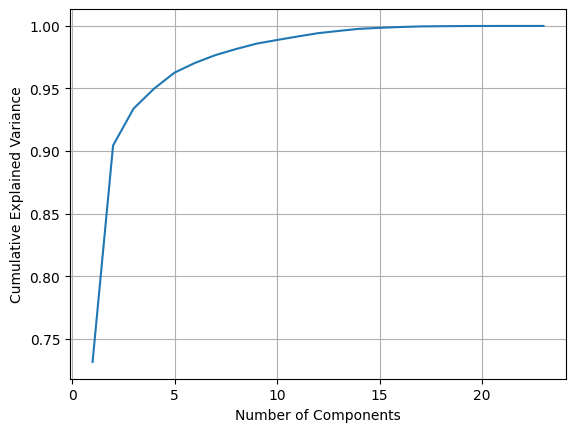

In [101]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot(
    range(1, len(pca.explained_variance_ratio_)+1),
    np.cumsum(pca.explained_variance_ratio_)
)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()
plt.show()

In [102]:
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train_scaled)

In [103]:
X_train_pca.shape

(350000, 5)

In [104]:
pca_cols = [f"PC{i+1}" for i in range(X_train_pca.shape[1])]

X_train_pca_df = pd.DataFrame(
    X_train_pca,
    columns=pca_cols
)

In [105]:
X_train_pca_df

,PC1,PC2,PC3,PC4,PC5
0,26.477718,0.535676,0.421754,-0.944705,-0.788971
1,-3.455468,-1.480541,-0.669084,1.807441,-1.336504
2,-3.432679,-1.434176,0.347616,0.802439,-0.740737
3,21.542387,0.188767,-0.593894,1.612722,-1.209415
4,-3.358864,-1.470297,-0.670377,2.843776,-1.335950
...,...,...,...,...,...
349995,-3.360078,-1.346902,-0.678726,-0.384665,0.859069
349996,-3.351542,-1.341524,-0.677571,-0.067994,0.921187
349997,-3.405876,-1.382445,-0.634214,-0.975805,-0.154918
349998,-3.370990,-1.356591,-0.706395,0.309609,0.940028


Done with feature engg

##### Saving the data

In [106]:
train_df.to_csv("train_df.csv", index=False)
val_df.to_csv("val_df.csv", index=False)
test_df.to_csv("test_df.csv", index=False)

In [107]:
X_train_pca_df.to_csv("X_train_pca.csv", index=False)

In [108]:
import joblib

joblib.dump(pca, "pca_model.pkl")

['pca_model.pkl']

In [114]:
# Count infinite values in numeric columns
inf_count = np.isinf(train_df.select_dtypes(include=[np.number])).sum().sum()
inf_count

np.int64(0)